# This notebook is to see how ResNet Performs on our problem cause why not

In [25]:
#loading data
import kagglehub
path = kagglehub.dataset_download("nirmalsankalana/rocole-a-robusta-coffee-leaf-images-dataset")

from google.colab import drive
drive.mount('/content/drive')

Using Colab cache for faster access to the 'rocole-a-robusta-coffee-leaf-images-dataset' dataset.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os
print(os.listdir(path))

['coffee___rust', 'coffee___red_spider_mite', 'coffee___healthy']


In [27]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import numpy as np

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [28]:
full_dataset = datasets.ImageFolder(path, transform=data_transforms)
target_classes = ["coffee___healthy", "coffee___rust"]

indices = [i for i, (_, label_idx) in enumerate(full_dataset.samples) 
           if full_dataset.classes[label_idx] in target_classes]

binary_dataset = Subset(full_dataset, indices)

In [29]:
drive_path = "/content/drive/MyDrive/deeplearning/data/coffeeevaluationdata"
drive_data = datasets.ImageFolder(root=drive_path, transform=data_transforms)

print(f"Original mapping found by ImageFolder: {drive_data.class_to_idx}")

# We create a transformation for the labels
# Folder '0' -> Class 0 (Healthy)
# Folders '2', '3', '4' -> Class 1 (Rust)
def binary_target_transform(label_idx):
    class_name = drive_data.classes[label_idx]
    return 0 if class_name == '0' else 1

drive_data.target_transform = binary_target_transform

# 3. Generate random indices for the 10% subset
total_size = len(drive_data)
subset_size = int(0.10 * total_size) # Calculate 10%

# Create a list of all indices and shuffle them
indices = np.arange(total_size)
np.random.shuffle(indices)

# Take only the first 10% of the shuffled indices
subset_indices = indices[:subset_size]

# 4. Create the Subset
drive_subset_data = Subset(drive_data, subset_indices)

# 5. Create the DataLoader using the subset
drive_test_loader = DataLoader(
    drive_subset_data, 
    batch_size=64, 
    shuffle=False, 
    num_workers=2
)

print(f"Original dataset size: {total_size}")
print(f"10% Subset size: {len(drive_subset_data)}")


Original mapping found by ImageFolder: {'0': 0, '2': 1, '3': 2, '4': 3}
Original dataset size: 2649
10% Subset size: 264


In [30]:
from torch.utils.data import random_split

train_size = int(0.7 * len(binary_dataset))
val_size = int(0.15 * len(binary_dataset))
test_size = len(binary_dataset) - train_size - val_size
train_data, val_data, test_data = random_split(binary_dataset, [train_size, val_size, test_size])

class BinaryCoffeeDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        binary_label = 0 if y == 0 else 1 
        return x, binary_label
        
    def __len__(self):
        return len(self.subset)

train_data = BinaryCoffeeDataset(train_data)
val_data = BinaryCoffeeDataset(val_data)
test_data = BinaryCoffeeDataset(test_data)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images: {len(test_data)}")

Training images: 975
Validation images: 208
Test images: 210


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [32]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights='IMAGENET1K_V1')

# 2. "Freeze" the feature extractor
# This prevents the pre-trained weights from being modified during the first phase
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final layer (the "Classifier")
# ResNet18's original head is designed for 1000 classes. We need it for 2.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

# 4. Move the model to the GPU
model = model.to(device)

print("ResNet18 is loaded and moved to GPU.")

ResNet18 is loaded and moved to GPU.


In [33]:
import torch.optim as optim

# Loss Function: Standard for classification
criterion = nn.CrossEntropyLoss()

# Optimizer: Only optimize the parameters of the final layer (the one we just replaced)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [38]:
from collections import Counter

def check_distribution(loader, name="Dataset"):
    counts = Counter()
    for _, labels in loader:
        # If your labels are on GPU, move to CPU and convert to list
        counts.update(labels.cpu().numpy())
    
    print(f"\n--- {name} Distribution ---")
    for label, count in sorted(counts.items()):
        label_name = "Healthy" if label == 0 else "Rust"
        print(f"Class {label} ({label_name}): {count} images")

# Usage:
check_distribution(train_loader, "Training Set")
check_distribution(drive_test_loader, "External Test Set")


--- Training Set Distribution ---
Class 0 (Healthy): 546 images
Class 1 (Rust): 429 images

--- External Test Set Distribution ---
Class 0 (Healthy): 177 images
Class 1 (Rust): 87 images


In [39]:
# 1. Initialize history dictionary
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'external_val_loss': [], 'external_val_acc': []
}

epochs = 10

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.long().to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    # Calculate and store train metrics
    epoch_train_loss = running_loss / len(train_data)
    epoch_train_acc = 100 * correct_train / total_train
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    running_outer_val_loss, correct_outer_val, total_outer_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.long().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

        for images, labels in drive_test_loader:
            images, labels = images.to(device), labels.long().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_outer_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_outer_val += labels.size(0)
            correct_outer_val += (predicted == labels).sum().item()
            
    # Calculate and store val metrics
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = 100 * correct_val / total_val
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    epoch_outer_val_loss = running_outer_val_loss / total_outer_val
    epoch_outer_val_acc = 100 * correct_outer_val / total_outer_val
    history['external_val_loss'].append(epoch_outer_val_loss)
    history['external_val_acc'].append(epoch_outer_val_acc)
    


    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | External Val Acc: {epoch_outer_val_acc:.2f}%")

Epoch [1/10] | Train Acc: 85.64% | Val Acc: 83.65% | External Val Acc: 73.11%
Epoch [2/10] | Train Acc: 86.56% | Val Acc: 85.10% | External Val Acc: 65.91%
Epoch [3/10] | Train Acc: 85.13% | Val Acc: 85.10% | External Val Acc: 64.02%
Epoch [4/10] | Train Acc: 84.51% | Val Acc: 85.58% | External Val Acc: 57.58%
Epoch [5/10] | Train Acc: 86.05% | Val Acc: 85.10% | External Val Acc: 70.08%
Epoch [6/10] | Train Acc: 88.10% | Val Acc: 84.13% | External Val Acc: 60.98%
Epoch [7/10] | Train Acc: 86.15% | Val Acc: 85.10% | External Val Acc: 70.45%
Epoch [8/10] | Train Acc: 87.18% | Val Acc: 85.10% | External Val Acc: 71.97%
Epoch [9/10] | Train Acc: 88.51% | Val Acc: 84.13% | External Val Acc: 65.91%
Epoch [10/10] | Train Acc: 88.31% | Val Acc: 79.33% | External Val Acc: 43.56%


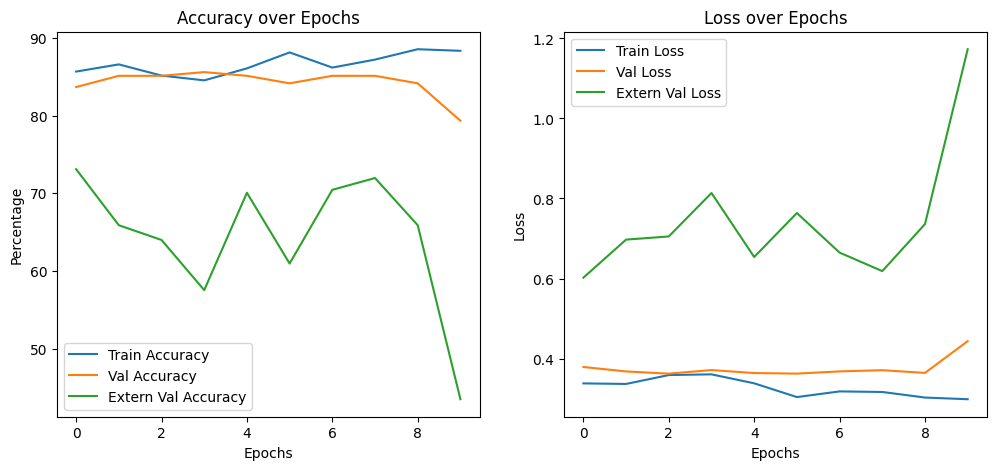

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.plot(history['external_val_acc'], label='Extern Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Percentage')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.plot(history['external_val_loss'], label='Extern Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()